# 12 — Cohort Heatmap
**When to use:** Understand retention or conversion behavior of users grouped by when they first entered the funnel.

Example: users who started the card application in week 1 — how many completed each subsequent step in weeks 2, 3, 4?

The heatmap encodes values as color intensity — easy to spot patterns across many cohorts at once.

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

df = pd.read_csv('data/raw/funnel_data.csv', parse_dates=['date'])
df['week'] = df['date'].dt.isocalendar().week.astype(int)
print(df.shape)

(450, 13)


## 1. Funnel cohort heatmap — CVR by acquisition week and channel

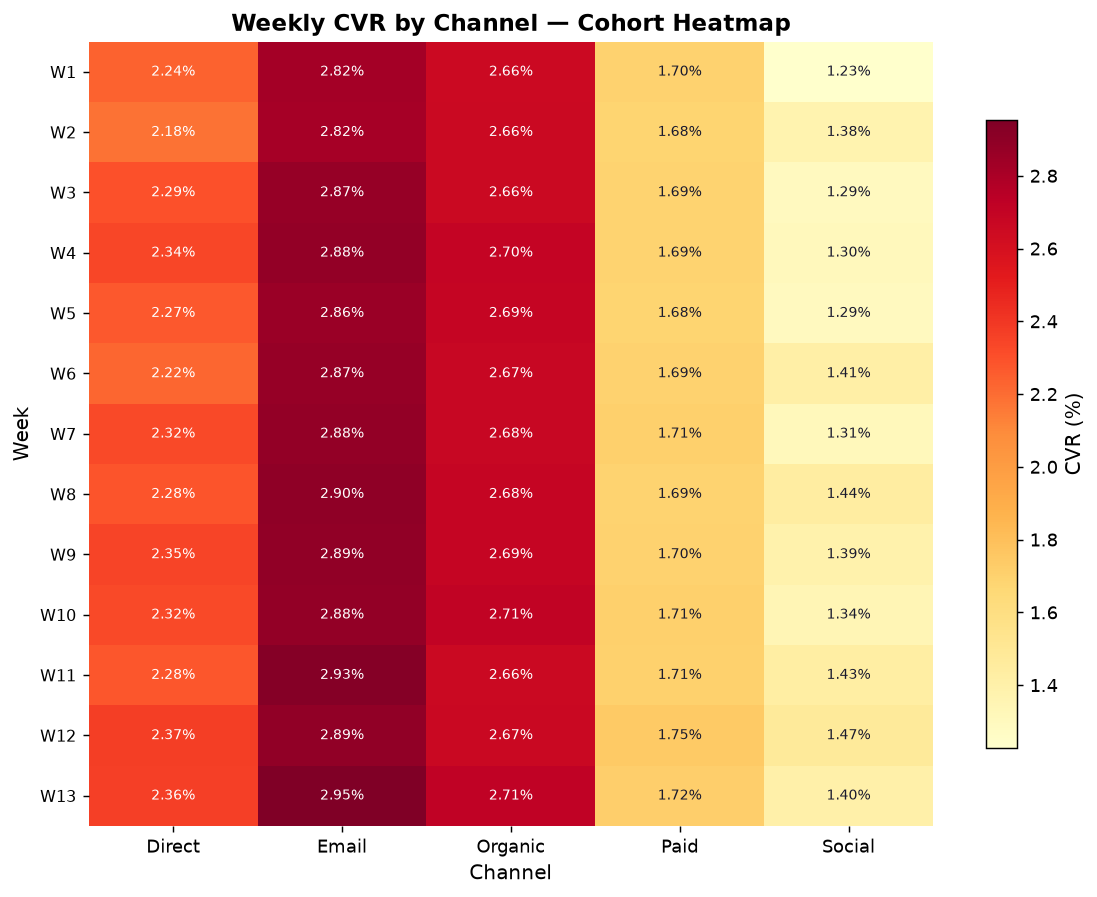

In [2]:
# Weekly CVR per channel — rows = weeks, columns = channels
pivot = df.groupby(['week', 'channel']).apply(
    lambda g: g['activacion_tarjeta'].sum() / g['visita_landing'].sum() * 100
).unstack('channel')

fig, ax = plt.subplots(figsize=(9, 7), dpi=130)

# imshow renders the 2D array as a colored grid
im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto',
                vmin=pivot.values.min(), vmax=pivot.values.max())

# Colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('CVR (%)', fontsize=11)

# Axis labels
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([c.capitalize() for c in pivot.columns], fontsize=10)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f'W{w}' for w in pivot.index], fontsize=9)

# Value annotations inside each cell
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            # Use white text on dark cells
            text_color = 'white' if val > pivot.values.max() * 0.6 else '#1a1a2e'
            ax.text(j, i, f'{val:.2f}%',
                    ha='center', va='center', fontsize=8, color=text_color)

ax.set_title('Weekly CVR by Channel — Cohort Heatmap',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Channel', fontsize=11)
ax.set_ylabel('Week', fontsize=11)
ax.spines[:].set_visible(False)

plt.tight_layout()
plt.savefig('data/12_cohort_heatmap_cvr.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Funnel step heatmap — where does each channel lose users?

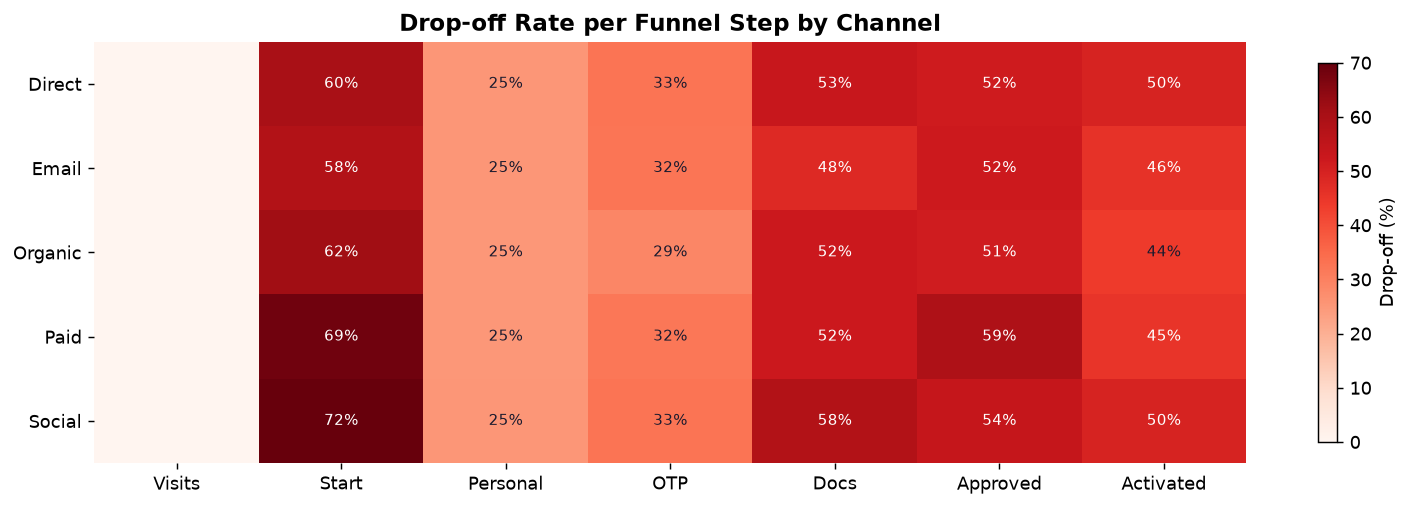

In [3]:
STEPS  = ['visita_landing','inicio_solicitud','datos_personales','otp',
           'carga_documentos','aprobacion','activacion_tarjeta']
LABELS = ['Visits','Start','Personal','OTP','Docs','Approved','Activated']

# Drop-off rate per step per channel
channels = sorted(df['channel'].unique())
drop_matrix = []

for ch in channels:
    totals = df[df['channel'] == ch][STEPS].sum()
    drops  = [0]  # no drop at first step
    for i in range(1, len(STEPS)):
        prev = totals[STEPS[i-1]]
        curr = totals[STEPS[i]]
        drops.append((prev - curr) / prev * 100 if prev > 0 else 0)
    drop_matrix.append(drops)

matrix = np.array(drop_matrix)   # shape: (n_channels, n_steps)

fig, ax = plt.subplots(figsize=(12, 4), dpi=130)

# Diverging colormap: white = no drop, red = high drop
im = ax.imshow(matrix, cmap='Reds', aspect='auto', vmin=0, vmax=70)

cbar = plt.colorbar(im, ax=ax, shrink=0.9, orientation='vertical')
cbar.set_label('Drop-off (%)', fontsize=10)

ax.set_xticks(range(len(LABELS)))
ax.set_xticklabels(LABELS, fontsize=10)
ax.set_yticks(range(len(channels)))
ax.set_yticklabels([c.capitalize() for c in channels], fontsize=10)

# Annotate each cell
for i in range(len(channels)):
    for j in range(len(STEPS)):
        val = matrix[i, j]
        text_color = 'white' if val > 45 else '#1a1a2e'
        ax.text(j, i, f'{val:.0f}%' if val > 0 else '',
                ha='center', va='center', fontsize=8.5, color=text_color)

ax.set_title('Drop-off Rate per Funnel Step by Channel',
             fontsize=13, fontweight='bold')
ax.spines[:].set_visible(False)

plt.tight_layout()
plt.savefig('data/12_cohort_heatmap_dropoff.png', dpi=150, bbox_inches='tight')
plt.show()

# Reading this: dark red cell = big problem for that channel at that step.
# Much faster to spot than comparing 5 separate bar charts.

## 3. Useful colormaps for analytics heatmaps

| Colormap | Best for |
|---|---|
| `'Reds'` | Drop-off, churn, errors (higher = worse) |
| `'Greens'` | Conversion, retention (higher = better) |
| `'YlOrRd'` | CVR, revenue (yellow = low, red = high) |
| `'RdYlGn'` | Performance vs target (red = bad, green = good) |
| `'RdBu'` | Diverging (positive vs negative change) |
| `'Blues'` | Neutral intensity (volume, frequency) |

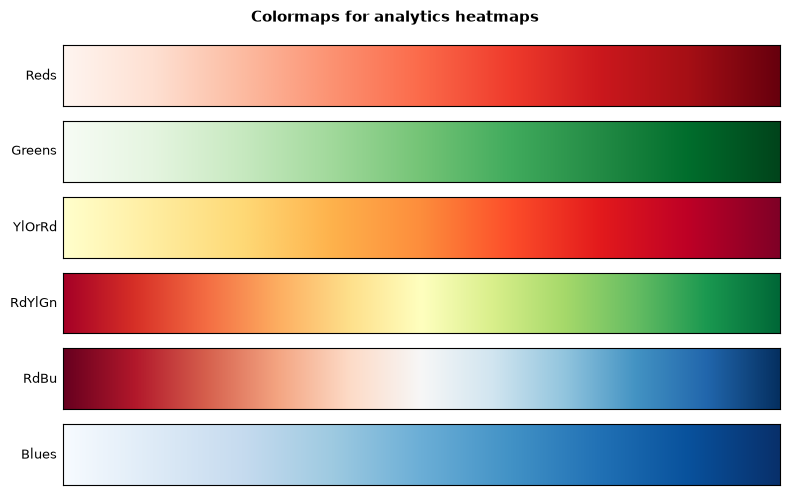

In [4]:
# Quick visual of colormap options
cmaps = ['Reds', 'Greens', 'YlOrRd', 'RdYlGn', 'RdBu', 'Blues']
gradient = np.linspace(0, 1, 256).reshape(1, -1)

fig, axes = plt.subplots(len(cmaps), 1, figsize=(8, 5), dpi=100)
for ax, cmap in zip(axes, cmaps):
    ax.imshow(gradient, aspect='auto', cmap=cmap)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_ylabel(cmap, fontsize=9, rotation=0, ha='right', va='center')

fig.suptitle('Colormaps for analytics heatmaps', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary
| Concept | Key point |
|---|---|
| **Build it** | `ax.imshow(matrix, cmap=..., vmin=, vmax=)` |
| **Labels** | `ax.set_xticks` + `ax.set_xticklabels` |
| **Values in cells** | `ax.text(j, i, val)` in a nested loop |
| **Colorbar** | `plt.colorbar(im, ax=ax)` |
| **Remove spines** | `ax.spines[:].set_visible(False)` |
| **Best for** | Spot patterns across many segments and steps at once |